# SCH-MGMT 661: Applications of AI Models  
**Instructor:** Indika Dissanayake  

---
### Introduction to YOLO and Faster R-CNN for Object Detection

---

### Overview: Object Detection Models
In this short tutorial, we introduce two of the most widely used deep learning models for object detection:

- YOLO (You Only Look Once) – A one-stage, real-time detector

- Faster R-CNN – A two-stage detector

The objective is to help you understand how both models work at a high level and how to run them on a single example image. This will prepare you for the more advanced object detection project you will complete later.

---
Demo Image Used

We will use one sample image downloaded from the web for demonstration purposes. The image will be processed by: YOLOv8 (Ultralytics), Faster R-CNN (TensorFlow Hub)

Both models will draw bounding boxes and labels on the same image, allowing you to visually compare their outputs.

# YOLO (You Only Look Once) – A one-stage detector

In [ ]:
#Install YOLOv8 (Ultralytics) and import dependencies

!pip install ultralytics
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 67.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Load YOLOv8n Pretrained Model (Nano Version)
model = YOLO('yolov8n.pt')

In [ ]:

# Download and load sample image

import urllib.request


image_url = "https://ultralytics.com/images/zidane.jpg"
urllib.request.urlretrieve(image_url, "image1.jpg")
image = cv2.imread("image1.jpg")


0: 384x640 2 persons, 1 tie, 107.7ms
Speed: 15.3ms preprocess, 107.7ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)


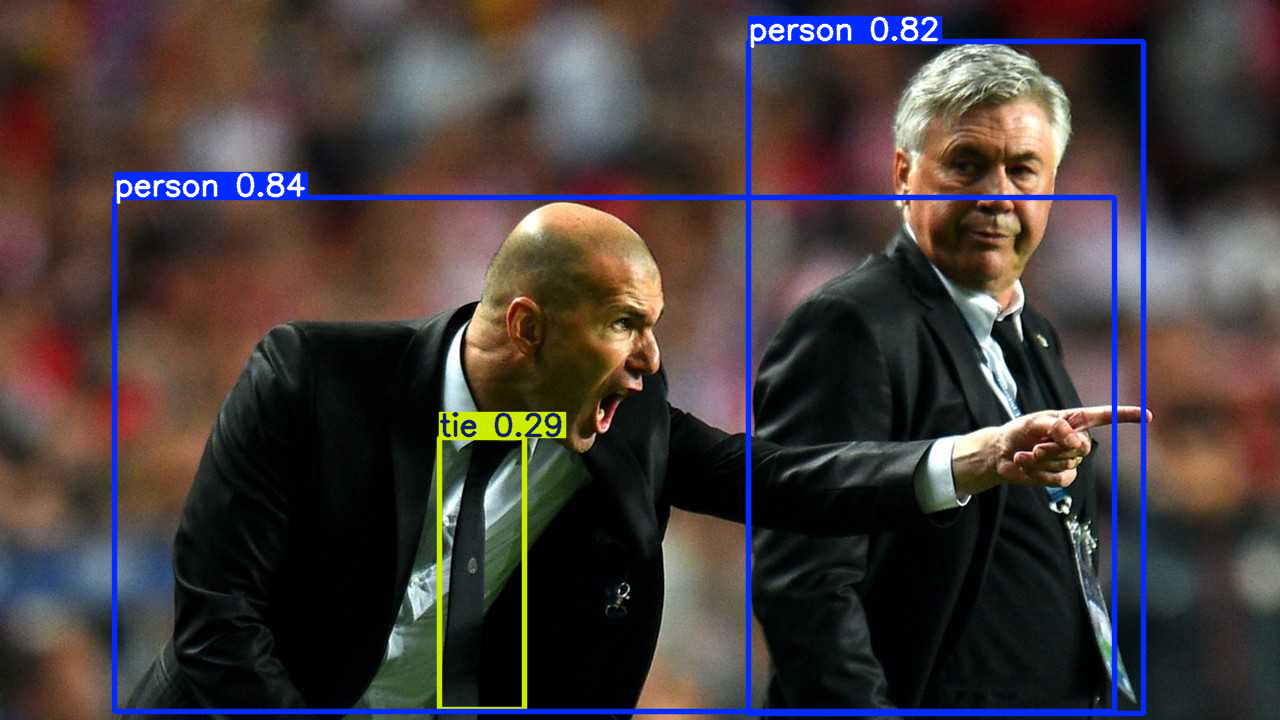

In [ ]:
# Run YOLOv8n detection
results = model(image)

# Visualize  annotationted detection
annotated_img = results[0].plot() # Includes bounding boxes and labels
cv2_imshow(annotated_img)



In [ ]:
# Print Detected Classes and Total Detections

print(f"Total objects detected: {len(results[0].boxes)}")
print(f"Detected classes: {list(set(results[0].boxes.cls))}")

Total objects detected: 3
Detected classes: [tensor(0., device='cuda:0'), tensor(0., device='cuda:0'), tensor(27., device='cuda:0')]


In [ ]:
# Access box info programmatically
for box in results[0].boxes:
    print("Object type:", box.cls)  # Class ID
    print("Coordinates:", box.xyxy)  # Bounding box [x1, y1, x2, y2]
    print("Confidence:", box.conf)   # Detection score

Object type: tensor([0.], device='cuda:0')
Coordinates: tensor([[ 114.9038,  197.4135, 1114.5022,  711.8817]], device='cuda:0')
Confidence: tensor([0.8358], device='cuda:0')
Object type: tensor([0.], device='cuda:0')
Coordinates: tensor([[ 748.4675,   41.8461, 1143.0909,  713.0194]], device='cuda:0')
Confidence: tensor([0.8190], device='cuda:0')
Object type: tensor([27.], device='cuda:0')
Coordinates: tensor([[439.4869, 437.0750, 524.3458, 709.1497]], device='cuda:0')
Confidence: tensor([0.2913], device='cuda:0')


# Faster R-CNN Object Detection

In [ ]:
# Import Required Libraries
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np

# Load pre-trained Faster R-CNN Model from TensorFlow Hub
model = hub.load("https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_640x640/1")


In [ ]:
# Load and preprocess input image
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
resized_image = cv2.resize(image_rgb, (640, 640))
input_tensor = tf.convert_to_tensor(resized_image, dtype=tf.uint8)[tf.newaxis, ...]


In [ ]:
# Run inference
detections = model(input_tensor)



In [ ]:
# Process outputs (Process Output (Convert Normalized Boxes to Original Scale))
boxes = detections['detection_boxes'][0].numpy()  # format [y1, x1, y2, x2]
boxes *= [image.shape[0], image.shape[1], image.shape[0], image.shape[1]]
scores = detections['detection_scores'][0].numpy()
classes = detections['detection_classes'][0].numpy().astype(int)

Faster R-CNN gives many overlapping candidate boxes.
Your code was drawing every high-score box, so duplicates stayed.
YOLO has NMS built in

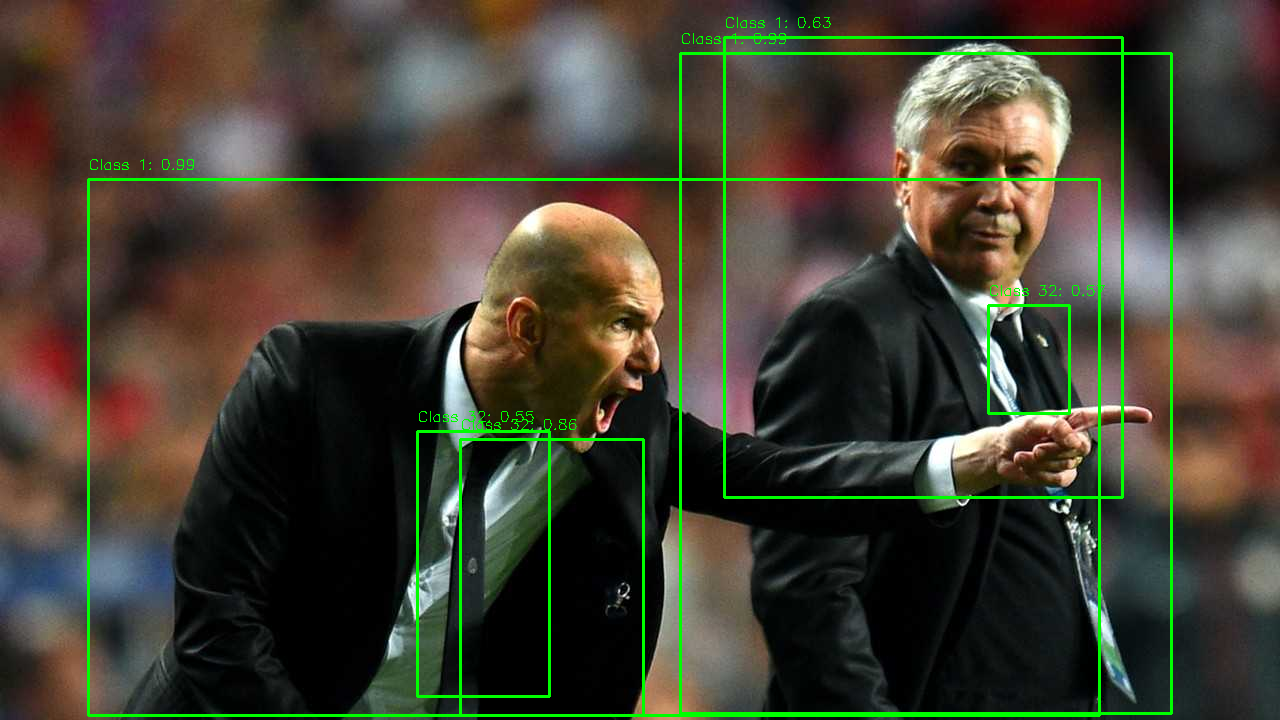

In [ ]:
# Visualize Detections (Only show boxes with score > 0.5)

for box, score, cls in zip(boxes, scores, classes):
    if score > 0.5:  # Confidence threshold
        y1, x1, y2, x2 = map(int, box)
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, f"Class {cls}: {score:.2f}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

cv2_imshow(image)



In [ ]:
# Confidence threshold
threshold = 0.5

# Filter detections by confidence
mask = scores > threshold
filtered_boxes = boxes[mask]
filtered_scores = scores[mask]
filtered_classes = classes[mask]

print(f"Total objects detected (score > {threshold}): {len(filtered_boxes)}")
print(f"Detected class IDs: {set(filtered_classes)}")

# Detailed per-object printout
for i, (box, score, cls_id) in enumerate(zip(filtered_boxes, filtered_scores, filtered_classes)):
    y1, x1, y2, x2 = map(int, box)

    print(f"\nObject {i+1}:")
    print(f"  Class ID: {cls_id}")
    print(f"  Confidence: {score:.4f}")
    print(f"  Bounding Box (pixel coords):")
    print(f"    xmin: {x1}, ymin: {y1}, xmax: {x2}, ymax: {y2}")


Total objects detected (score > 0.5): 6
Detected class IDs: {np.int64(32), np.int64(1)}

Object 1:
  Class ID: 1
  Confidence: 0.9935
  Bounding Box (pixel coords):
    xmin: 680, ymin: 53, xmax: 1171, ymax: 713

Object 2:
  Class ID: 1
  Confidence: 0.9913
  Bounding Box (pixel coords):
    xmin: 88, ymin: 179, xmax: 1099, ymax: 715

Object 3:
  Class ID: 32
  Confidence: 0.8564
  Bounding Box (pixel coords):
    xmin: 460, ymin: 439, xmax: 643, ymax: 715

Object 4:
  Class ID: 1
  Confidence: 0.6273
  Bounding Box (pixel coords):
    xmin: 724, ymin: 37, xmax: 1122, ymax: 497

Object 5:
  Class ID: 32
  Confidence: 0.5706
  Bounding Box (pixel coords):
    xmin: 988, ymin: 305, xmax: 1069, ymax: 413

Object 6:
  Class ID: 32
  Confidence: 0.5470
  Bounding Box (pixel coords):
    xmin: 417, ymin: 431, xmax: 549, ymax: 696
